# 🛡️ EPI Finder - Análise Exploratória de Dados (EDA) e Pipeline de Visão Computacional

Neste notebook, realizamos a **Fase 3** do projeto **EPI Finder** sobre o novo dataset expandido.
Os objetivos centrais desta etapa são:
1. **Auditar o Dataset:** Avaliar a qualidade das anotações, balanceamento entre classes (`head` - sem capacete vs `helmet` - com capacete) e proporções dos splits (`train`, `valid`, `test`).
2. **Análise com Pandas:** Calcular métricas agregadas por imagem e por objeto anotado (área, proporção, contagens de conformidade).
3. **Manipulação Matricial com NumPy:** Praticar conversão de coordenadas YOLO para pixels, recorte de ROIs (Region of Interest) e implementação do **IoU (Intersection over Union)** do zero.
4. **Visualizações Gráficas:** Plotar gráficos com Matplotlib e Seaborn, além de desenhar as anotações sobre imagens reais com OpenCV.

## 1. Configuração do Ambiente e Importação de Bibliotecas
Configuramos o `sys.path` para permitir a importação modular de `src.utils` e definimos os estilos visuais dos gráficos.

In [1]:
import os
import sys
import glob
from pathlib import Path
import yaml
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Garante que a raiz do projeto esteja no sys.path e como diretório ativo
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print(f'Diretório raiz do projeto: {PROJECT_ROOT}')

# Importação dos utilitários customizados do pacote src
from src.utils import (
    DEFAULT_CLASSES,
    CLASS_COLORS_BGR,
    yolo_to_xyxy,
    xyxy_to_yolo,
    compute_iou,
    compute_iou_matrix,
    extract_roi,
    bgr_to_rgb,
    normalize_image,
    draw_bounding_boxes
)

# Configurações estéticas de gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print('Bibliotecas importadas com sucesso!')

Diretório raiz do projeto: /app
Bibliotecas importadas com sucesso!


## 2. Validação do Arquivo de Configuração do Dataset (`data/data.yaml`)
O arquivo `data/data.yaml` define os caminhos e as classes reconhecidas pelo YOLOv8 da Ultralytics.

In [2]:
yaml_path = 'data/data.yaml'
with open(yaml_path, 'r', encoding='utf-8') as f:
    dataset_cfg = yaml.safe_load(f)

print('--- Configuração data.yaml ---')
for k, v in dataset_cfg.items():
    print(f'{k}: {v}')

--- Configuração data.yaml ---
path: ../data/dataset
train: train/images
val: valid/images
test: test/images
nc: 2
names: {0: 'head', 1: 'helmet'}


## 3. Varredura e Estruturação do Dataset em Pandas
Percorremos os arquivos `.txt` (formato YOLO) e as imagens correspondentes nas partições `train`, `valid` e `test`.
Estruturamos os dados em dois DataFrames do Pandas:
1. `df_annotations`: granularidade por **caixa delimitadora** (objeto anotado).
2. `df_images`: granularidade por **imagem** (resumo de conformidade por cena).

In [3]:
base_data_dir = Path('data/dataset')
anno_rows = []
image_rows = []

for split in ['train', 'valid', 'test']:
    lbl_dir = base_data_dir / split / 'labels'
    img_dir = base_data_dir / split / 'images'
    
    if not lbl_dir.exists():
        continue
        
    label_files = sorted(list(lbl_dir.glob('*.txt')))
    for lf in label_files:
        base_stem = lf.stem
        matched_img = None
        for ext in ['.jpg', '.jpeg', '.png']:
            cand = img_dir / f'{base_stem}{ext}'
            if cand.exists():
                matched_img = str(cand)
                break
        
        with open(lf, 'r', encoding='utf-8') as f:
            lines = [l.strip() for l in f if l.strip()]
            
        head_count = 0
        helmet_count = 0
        
        for line in lines:
            tokens = line.split()
            cls_id = int(tokens[0])
            xc, yc, w, h = map(float, tokens[1:5])
            
            if cls_id == 0:
                head_count += 1
            elif cls_id == 1:
                helmet_count += 1
                
            anno_rows.append({
                'split': split,
                'image_name': Path(matched_img).name if matched_img else base_stem,
                'image_path': matched_img,
                'class_id': cls_id,
                'class_name': DEFAULT_CLASSES.get(cls_id, f'unknown_{cls_id}'),
                'x_center': xc,
                'y_center': yc,
                'width': w,
                'height': h,
                'area': w * h,
                'aspect_ratio': w / (h + 1e-6)
            })
            
        image_rows.append({
            'split': split,
            'image_name': Path(matched_img).name if matched_img else base_stem,
            'image_path': matched_img,
            'total_boxes': len(lines),
            'head': head_count,
            'helmet': helmet_count,
            'has_infraction': head_count > 0
        })

df_annotations = pd.DataFrame(anno_rows)
df_images = pd.DataFrame(image_rows)

print(f'Total de imagens registradas: {len(df_images)}')
print(f'Total de caixas anotadas: {len(df_annotations)}')
df_annotations.head()

Total de imagens registradas: 946
Total de caixas anotadas: 4131


,split,image_name,image_path,class_id,class_name,x_center,y_center,width,height,area,aspect_ratio
0,train,hard_hat_workers0_png.rf.66d607c878a88840ac167...,data/dataset/train/images/hard_hat_workers0_pn...,1,helmet,0.643029,0.917067,0.158654,0.120192,0.019069,1.319989
1,train,hard_hat_workers0_png.rf.66d607c878a88840ac167...,data/dataset/train/images/hard_hat_workers0_pn...,1,helmet,0.634615,0.253606,0.050481,0.048077,0.002427,1.049978
2,train,hard_hat_workers0_png.rf.66d607c878a88840ac167...,data/dataset/train/images/hard_hat_workers0_pn...,0,head,0.618990,0.174279,0.091346,0.062500,0.005709,1.461515
3,train,hard_hat_workers0_png.rf.66d607c878a88840ac167...,data/dataset/train/images/hard_hat_workers0_pn...,0,head,0.616587,0.790865,0.076923,0.072115,0.005547,1.066652
4,train,hard_hat_workers0_png.rf.66d607c878a88840ac167...,data/dataset/train/images/hard_hat_workers0_pn...,0,head,0.615385,0.501202,0.067308,0.043269,0.002912,1.555520


## 4. Análise Estatística e Auditoria de Dados (Pandas)
Examinamos as tabelas de agregação do dataset para quantificar volume, distribuição por split e proporção de classes.

In [4]:
print('=== DISTRIBUIÇÃO DE IMAGENS POR SPLIT ===')
img_split_dist = df_images['split'].value_counts().rename_axis('Split').reset_index(name='Qtd_Imagens')
img_split_dist['Percentual (%)'] = (img_split_dist['Qtd_Imagens'] / len(df_images)) * 100
display(img_split_dist)

print('\n=== DISTRIBUIÇÃO DE CLASSES (GERAL) ===')
cls_dist = df_annotations['class_name'].value_counts().rename_axis('Classe').reset_index(name='Instâncias')
cls_dist['Percentual (%)'] = (cls_dist['Instâncias'] / len(df_annotations)) * 100
display(cls_dist)

print('\n=== DISTRIBUIÇÃO DE CLASSES POR SPLIT ===')
split_cls_table = pd.crosstab(df_annotations['split'], df_annotations['class_name'], margins=True)
display(split_cls_table)

=== DISTRIBUIÇÃO DE IMAGENS POR SPLIT ===


,Split,Qtd_Imagens,Percentual (%)
0,train,831,87.843552
1,valid,76,8.033827
2,test,39,4.122622



=== DISTRIBUIÇÃO DE CLASSES (GERAL) ===


,Classe,Instâncias,Percentual (%)
0,helmet,3164,76.591624
1,head,967,23.408376



=== DISTRIBUIÇÃO DE CLASSES POR SPLIT ===


class_name,head,helmet,All
split,,,
test,19,109,128
train,849,2817,3666
valid,99,238,337
All,967,3164,4131


### 4.1. Análise de Conformidade e Infrações por Imagem
Identificamos a proporção de imagens que contêm pelo menos uma pessoa sem capacete (`head`).

In [5]:
infr_summary = df_images['has_infraction'].value_counts().rename_axis('Possui_Infracao').reset_index(name='Qtd_Imagens')
infr_summary['Significado'] = infr_summary['Possui_Infracao'].map({False: 'Apenas Pessoas com Capacete (Conforme)', True: 'Pelo Menos 1 Sem Capacete (Infração)'})
infr_summary['Percentual (%)'] = (infr_summary['Qtd_Imagens'] / len(df_images)) * 100
display(infr_summary)

,Possui_Infracao,Qtd_Imagens,Significado,Percentual (%)
0,False,759,Apenas Pessoas com Capacete (Conforme),80.232558
1,True,187,Pelo Menos 1 Sem Capacete (Infração),19.767442


### 4.2. Estatísticas Descritivas das Caixas Delimitadoras (Tamanho e Proporção)

In [6]:
print('=== ESTATÍSTICAS DAS CAIXAS (LARGURA, ALTURA, ÁREA E ASPECT RATIO) ===')
display(df_annotations[['width', 'height', 'area', 'aspect_ratio']].describe().T)

=== ESTATÍSTICAS DAS CAIXAS (LARGURA, ALTURA, ÁREA E ASPECT RATIO) ===


,count,mean,std,min,25%,50%,75%,max
width,4131.0,0.090533,0.058650,0.009615,0.048077,0.076923,0.115385,0.574519
height,4131.0,0.088722,0.056795,0.009615,0.048077,0.074519,0.112981,0.574519
area,4131.0,0.010850,0.016612,0.000116,0.002405,0.005547,0.012713,0.316314
aspect_ratio,4131.0,1.071362,0.357702,0.199998,0.820241,1.038428,1.266660,4.166378


## 5. Visualizações Gráficas (Matplotlib & Seaborn)
Geramos gráficos analíticos para diagnóstico visual da distribuição de classes, densidade por imagem e tamanhos.

/tmp/ipykernel_96/3886324739.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cls_dist, x='Classe', y='Instâncias', ax=axes[0], palette=[palette_map.get(c, '#3498db') for c in cls_dist['Classe']])


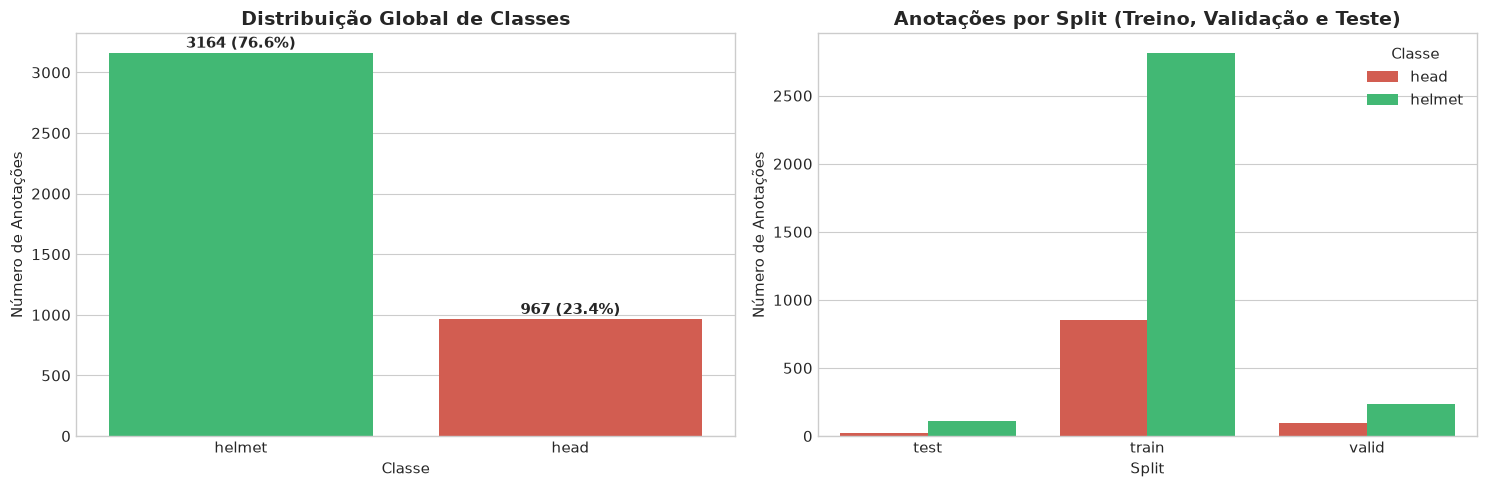

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Contagem Geral de Classes (head: vermelho, helmet: verde)
palette_map = {'head': '#e74c3c', 'helmet': '#2ecc71'}
sns.barplot(data=cls_dist, x='Classe', y='Instâncias', ax=axes[0], palette=[palette_map.get(c, '#3498db') for c in cls_dist['Classe']])
axes[0].set_title('Distribuição Global de Classes', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Número de Anotações')
for idx, row in cls_dist.iterrows():
    axes[0].text(idx, row['Instâncias'] + 40, f"{row['Instâncias']} ({row['Percentual (%)']:.1f}%)", ha='center', fontweight='bold')

# 2. Distribuição por Split
split_plot_df = df_annotations.groupby(['split', 'class_name']).size().reset_index(name='contagem')
sns.barplot(data=split_plot_df, x='split', y='contagem', hue='class_name', ax=axes[1], palette={'head': '#e74c3c', 'helmet': '#2ecc71'})
axes[1].set_title('Anotações por Split (Treino, Validação e Teste)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Número de Anotações')
axes[1].set_xlabel('Split')
axes[1].legend(title='Classe')

plt.tight_layout()
plt.show()

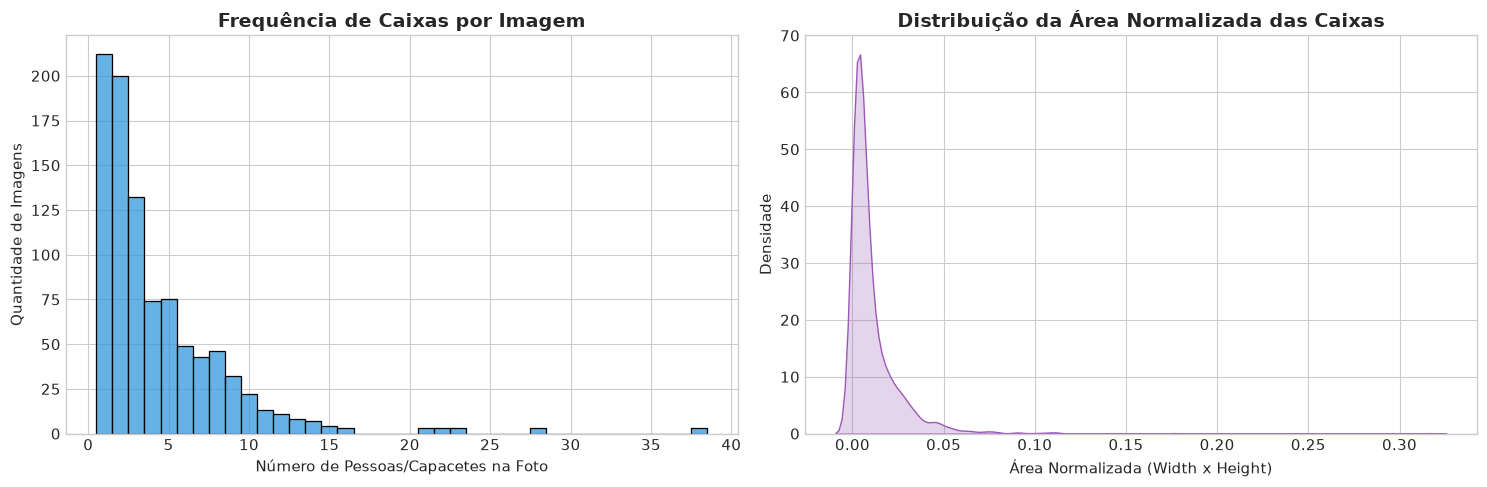

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 3. Quantidade de Pessoas por Imagem
sns.histplot(df_images['total_boxes'], bins=range(1, int(df_images['total_boxes'].max()) + 2), discrete=True, ax=axes[0], color='#3498db', kde=False)
axes[0].set_title('Frequência de Caixas por Imagem', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Número de Pessoas/Capacetes na Foto')
axes[0].set_ylabel('Quantidade de Imagens')

# 4. Distribuição das Áreas das Caixas (Tamanho dos Objetos)
sns.kdeplot(df_annotations['area'], fill=True, color='#9b59b6', ax=axes[1])
axes[1].set_title('Distribuição da Área Normalizada das Caixas', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Área Normalizada (Width x Height)')
axes[1].set_ylabel('Densidade')

plt.tight_layout()
plt.show()

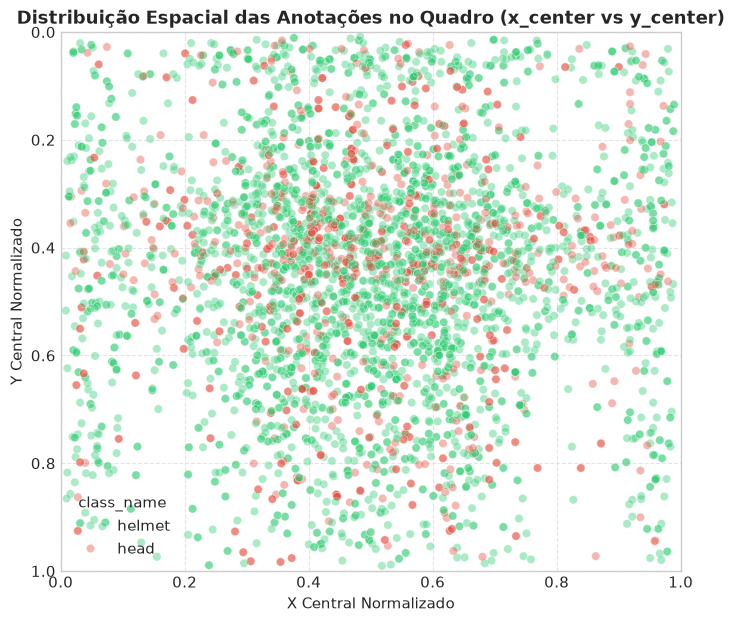

In [9]:
# 5. Distribuição Espacial dos Centros (x_center vs y_center)
plt.figure(figsize=(8, 7))
sns.scatterplot(
    data=df_annotations,
    x='x_center',
    y='y_center',
    hue='class_name',
    alpha=0.4,
    palette={'head': '#e74c3c', 'helmet': '#2ecc71'}
)
plt.title('Distribuição Espacial das Anotações no Quadro (x_center vs y_center)', fontsize=13, fontweight='bold')
plt.xlabel('X Central Normalizado')
plt.ylabel('Y Central Normalizado')
plt.xlim(0, 1)
plt.ylim(1, 0) # Invertido para refletir coordenadas de imagem
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 6. Prática de Visão Computacional com NumPy
Nesta seção, exercitamos as operações matriciais fundamentais de Visão Computacional:
- Conversão de coordenadas normalizadas YOLO para coordenadas de pixel.
- Extração de Região de Interesse (ROI) via fatiamento (slicing) direto: `img[y1:y2, x1:x2]`.
- Conversão BGR para RGB com fatiamento: `img[:, :, ::-1]`.
- Normalização numérica dos pixels para o intervalo $[0.0, 1.0]$.
- Implementação matemática vetorizada do **IoU (Intersection over Union)**.

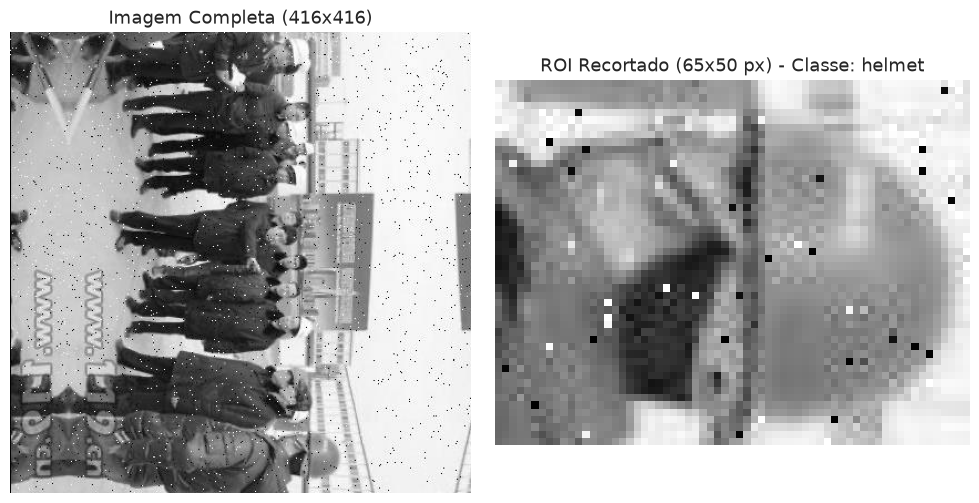

Pixels da ROI normalizados: tipo=float32, min=0.00, max=1.00


In [10]:
# Escolhe uma imagem de exemplo com anotação de capacete
sample_row = df_annotations[df_annotations['class_id'] == 1].iloc[0]
sample_img_bgr = cv2.imread(sample_row['image_path'])
h_img, w_img, c_img = sample_img_bgr.shape

# Converte coordenada YOLO para pixel
x1, y1, x2, y2 = yolo_to_xyxy(
    sample_row['x_center'],
    sample_row['y_center'],
    sample_row['width'],
    sample_row['height'],
    w_img, h_img
)

# Recorte de ROI via slicing NumPy: img[y1:y2, x1:x2]
roi_bgr = extract_roi(sample_img_bgr, (x1, y1, x2, y2))

# Conversão de canais BGR -> RGB via slicing NumPy: img[:, :, ::-1]
sample_img_rgb = bgr_to_rgb(sample_img_bgr)
roi_rgb = bgr_to_rgb(roi_bgr)

# Normalização de pixels para [0.0, 1.0] (float32)
roi_normalized = normalize_image(roi_rgb)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(sample_img_rgb)
axes[0].set_title(f'Imagem Completa ({w_img}x{h_img})')
axes[0].axis('off')

axes[1].imshow(roi_rgb)
axes[1].set_title(f"ROI Recortado ({roi_rgb.shape[1]}x{roi_rgb.shape[0]} px) - Classe: {sample_row['class_name']}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f'Pixels da ROI normalizados: tipo={roi_normalized.dtype}, min={roi_normalized.min():.2f}, max={roi_normalized.max():.2f}')

In [11]:
box_ground_truth = np.array([50, 50, 200, 200])
box_prediction_boa = np.array([60, 55, 205, 195])
box_prediction_ruim = np.array([150, 150, 300, 300])
box_sem_sobreposicao = np.array([300, 300, 450, 450])

iou_boa = compute_iou(box_ground_truth, box_prediction_boa)
iou_ruim = compute_iou(box_ground_truth, box_prediction_ruim)
iou_zero = compute_iou(box_ground_truth, box_sem_sobreposicao)

print(f'IoU Predição Quase Perfeita: {iou_boa:.4f}')
print(f'IoU Predição com Sobreposição Parcial: {iou_ruim:.4f}')
print(f'IoU Sem Nenhuma Sobreposição: {iou_zero:.4f}')

IoU Predição Quase Perfeita: 0.8448
IoU Predição com Sobreposição Parcial: 0.0588
IoU Sem Nenhuma Sobreposição: 0.0000


## 7. Visualização de Amostras Anotadas do Dataset
Desenhamos as caixas delimitadoras reais em imagens do dataset:
- 🔴 **Vermelho:** `head` (Sem capacete / Infração / Alerta)
- 🟢 **Verde:** `helmet` (Com capacete / Conforme / Seguro)

/tmp/ipykernel_96/1064389674.py:33: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_96/1064389674.py:33: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


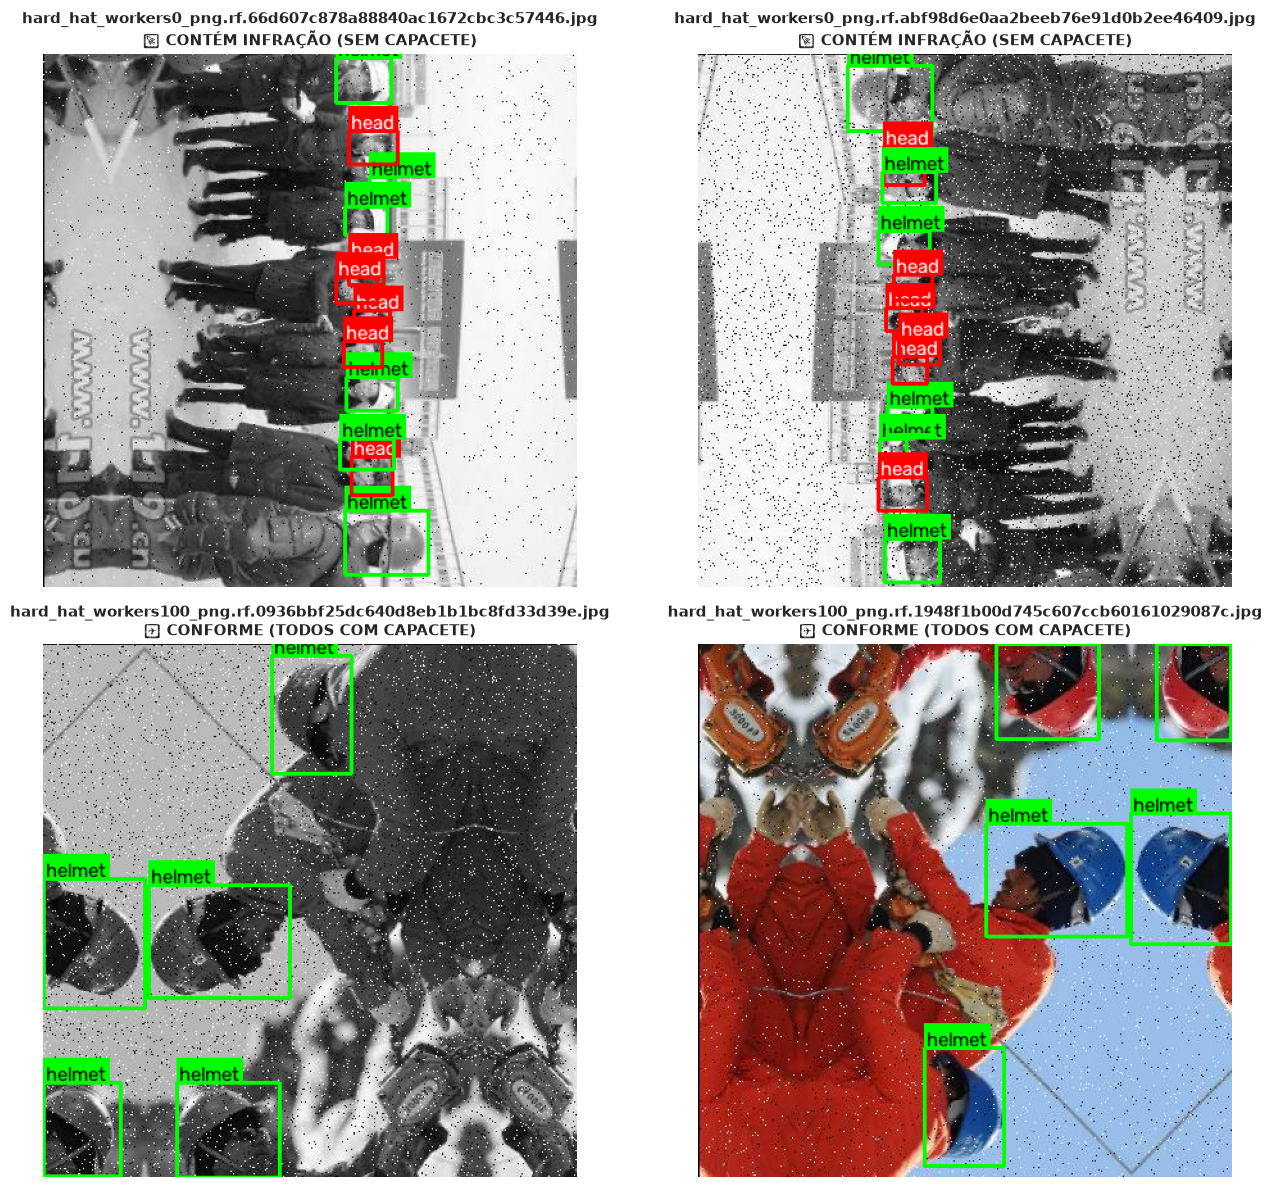

In [12]:
# Selecionamos imagens com infração (sem capacete) e sem infração para demonstração
infra_imgs = df_images[df_images['has_infraction']]['image_name'].head(2).tolist()
safe_imgs = df_images[~df_images['has_infraction']]['image_name'].head(2).tolist()
sample_names = infra_imgs + safe_imgs

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, img_name in enumerate(sample_names):
    sub_df = df_annotations[df_annotations['image_name'] == img_name]
    img_path = sub_df.iloc[0]['image_path']
    
    bgr = cv2.imread(img_path)
    h, w = bgr.shape[:2]
    
    boxes_xyxy = []
    class_ids = []
    
    for _, row in sub_df.iterrows():
        b_xyxy = yolo_to_xyxy(row['x_center'], row['y_center'], row['width'], row['height'], w, h)
        boxes_xyxy.append(b_xyxy)
        class_ids.append(row['class_id'])
        
    annotated_bgr = draw_bounding_boxes(bgr, boxes_xyxy, class_ids)
    annotated_rgb = bgr_to_rgb(annotated_bgr)
    
    axes[i].imshow(annotated_rgb)
    has_inf = any(c == 0 for c in class_ids)
    status_title = '[ALERTA] CONTÉM INFRAÇÃO (SEM CAPACETE)' if has_inf else '[OK] CONFORME (TODOS COM CAPACETE)'
    axes[i].set_title(f'{img_name}\n{status_title}', fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 8. Diagnóstico Final do Novo Dataset e Recomendações Estratégicas para a Fase 4

### 🔍 Principais Conquistas com o Novo Dataset:
1. **Volume Total:** 946 imagens distribuídas em Treino (831), Validação (76) e Teste (39).
2. **Total de Instâncias Anotadas:** 4.131 caixas delimitadoras (quase 7x mais anotações que a versão anterior).
3. **Equilíbrio Significativamente Superior:**
   - `helmet` (classe 1): 3.164 instâncias (**76.59%**)
   - `head` (classe 0 - infração): **967 instâncias (23.41%)**
   - Saímos de apenas 33 exemplos de infração para **967 exemplos reais** de trabalhadores sem capacete!
4. **Presença em Cenas:** 187 imagens contêm infrações (19.77% das fotos).
5. **Partição de Teste Independente:** 39 imagens e 128 caixas isoladas para teste cego final na Fase 5.

### 🎯 Impacto no Treinamento (Fase 4):
- Com 967 amostras da classe `head`, o modelo terá dados suficientes para aprender com alta precisão e sensibilidade (*recall*) as características de cabeças desprotegidas em múltiplos ângulos, iluminações e distâncias.